### references 
- https://www.youtube.com/watch?v=N-49t1j-XWY 
- https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/

### Imports

In [250]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import os
from data_cleaning_class import DataCleaner
from data_explorer_class import DataExplorer
import re
pd.set_option('display.max_rows', None)

### Loading

In [251]:
script_dir = os.getcwd()
csv_path = os.path.join(script_dir , "kl.csv")
print(csv_path)

decoded_df = pd.read_csv(csv_path , encoding="cp1252")


/home/youssef/mia_ai/Task_2/Task2.2/kl.csv


### Data Exploring

=== STATISTICS ===
         Unnamed: 0             ID           Age       Overall     Potential  \
count  18207.000000   18207.000000  18206.000000  18206.000000  18207.000000   
mean    9103.000000  214298.338606     25.122048     66.237449     71.307299   
std     5256.052511   29965.244204      4.670022      6.907059      6.136496   
min        0.000000      16.000000     16.000000     46.000000     48.000000   
25%     4551.500000  200315.500000     21.000000     62.000000     67.000000   
50%     9103.000000  221759.000000     25.000000     66.000000     71.000000   
75%    13654.500000  236529.500000     28.000000     71.000000     75.000000   
99%    18023.940000  246089.940000     36.000000     83.000000     87.000000   
max    18206.000000  246620.000000     45.000000     94.000000     95.000000   

            Special  International Reputation     Weak Foot   Skill Moves  \
count  18207.000000              18159.000000  18159.000000  18159.000000   
mean    1597.809908       

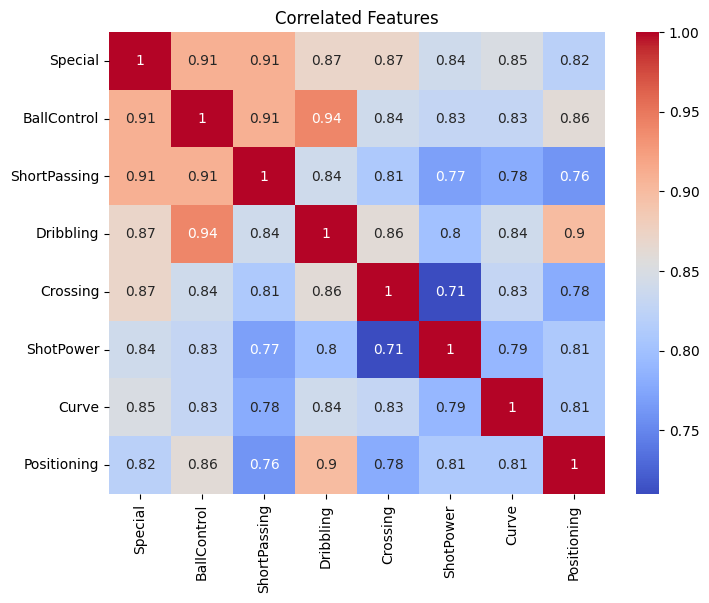

In [252]:
data_explorer = DataExplorer(csv_path) 
data_explorer.values_inspection()       #think i'll modify the class in the feature to exclude things like ID,unnamed,jersy number o.o
data_explorer.basic_structure()         #88 feature that's very high dimension relative to only 18207 sample
data_explorer.check_for_skewness()      # 
data_explorer.check_outliers()
data_explorer.get_duplicates()
data_explorer.get_correlations()        #some are very highly correlated , making them suitable for PCA
#i guess nationally can be important,since for example brazilians seems to be "talented", will look for a way to turn them into numerics for PCA , currently i'm thinking of a simple directory
#salary values should be stripped of € and turned into numerical while replacing k with 10^^3,..etc
#preferred foot can be mapped to [0,1]
# according to google Work Rate in FIFA is a two-part rating showing how actively a player moves without the ball
# i guess that's kinda important for defender so i'll map it too 
# others are already numerical so i'll keep them , i'll let the AI decide about those weird letters ones, but i'll keep as many as possible because i wanna see how PCA will determine most important factors


### Creating Numerical Dataset

In [253]:
drop_cols = ['Unnamed: 0', 'ID']
players_df = decoded_df.drop(columns=drop_cols)

position_cols = ['LS','ST','RS','LW','LF','CF','RF','RW','LAM','CAM','RAM','LM',
                  'LCM','CM','RCM','RM','LWB','LDM','CDM','RDM','RWB','LB','LCB',
                  'CB','RCB','RB']

for col in position_cols :
    players_df[col] = players_df[col].str.split("+" , expand= True).astype(float).sum(axis= 1)

# print (players_df[["LS" , "ST"]].head(10))

currency_cols = ['Value', 'Wage', 'Release Clause']
def parse_currency(val):
    val = str(val).replace('€', '').strip()
    multiplier = 1
    
    if val.endswith('M'):
        multiplier = 1_000_000
        val = val[:-1]
    elif val.endswith('K'):
        multiplier = 1_000
        val = val[:-1]
    try:
        return float(val) * multiplier
    except ValueError:
        return np.nan

for col in currency_cols:
    players_df[col] = players_df[col].apply(parse_currency)


# print(players_df[currency_cols].head(5))

def parse_height(val):
    if pd.isna(val):
        return np.nan

    val= str(val).split("'")
    val = [float(value) for value in val]
    val_inch = val[0] * 12 + val[1]
    val_cm   = val_inch * 2.54           #guess it doesn't matter since normalization is done anyway

    return float(val_cm)

players_df["Height"] =players_df["Height"].apply(parse_height)


def parse_weight(val) :
    if pd.isna(val) :
        return np.nan

    val = val.strip("lbs")
    return float(val)

players_df["Weight"] = players_df["Weight"].apply(parse_weight)

print(players_df['Preferred Foot'].value_counts()) #to make sure there is someone who doesn't prefer a special leg

players_df["Preferred Foot"] = (
    players_df["Preferred Foot"].str.strip() == "Left"
).astype(int)

players_df = players_df.select_dtypes(include = 'number')




Preferred Foot
Right    13948
Left      4211
Name: count, dtype: int64


### Cleaning

In [254]:
players_df = DataCleaner(players_df).clean_df()

### numpy Implementation


#### cov matrix

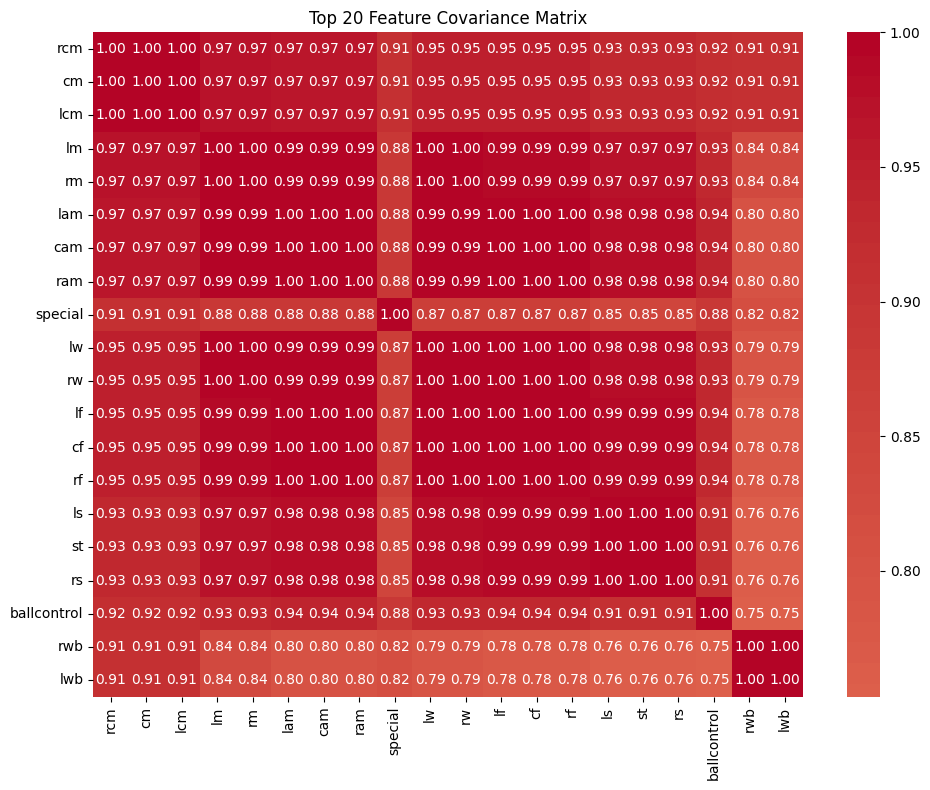

In [255]:
standardized_df = ((players_df - players_df.mean()) / players_df.std())
cov_matrix = np.cov(standardized_df, rowvar = False)

cov_df = pd.DataFrame(cov_matrix, index=standardized_df.columns, columns=standardized_df.columns)

# Rank features by total absolute covariance with all others
cov_magnitude = cov_df.abs()
np.fill_diagonal(cov_magnitude.values, 0)
scores = cov_magnitude.sum().sort_values(ascending=False)

top_features = scores.head(20).index
top_cov = cov_df.loc[top_features, top_features]

plt.figure(figsize=(10, 8))
sns.heatmap(top_cov, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Top 20 Feature Covariance Matrix')
plt.tight_layout()
plt.show()

#### Eigen-Decomposition

In [256]:
eigen_values , eigen_vectors = np.linalg.eigh(cov_matrix)

#sort descending
eigenvalues = eigen_values[::-1]
eigenvectors = eigen_vectors[:, ::-1]

#### PCA -2 

0.6792092467932531


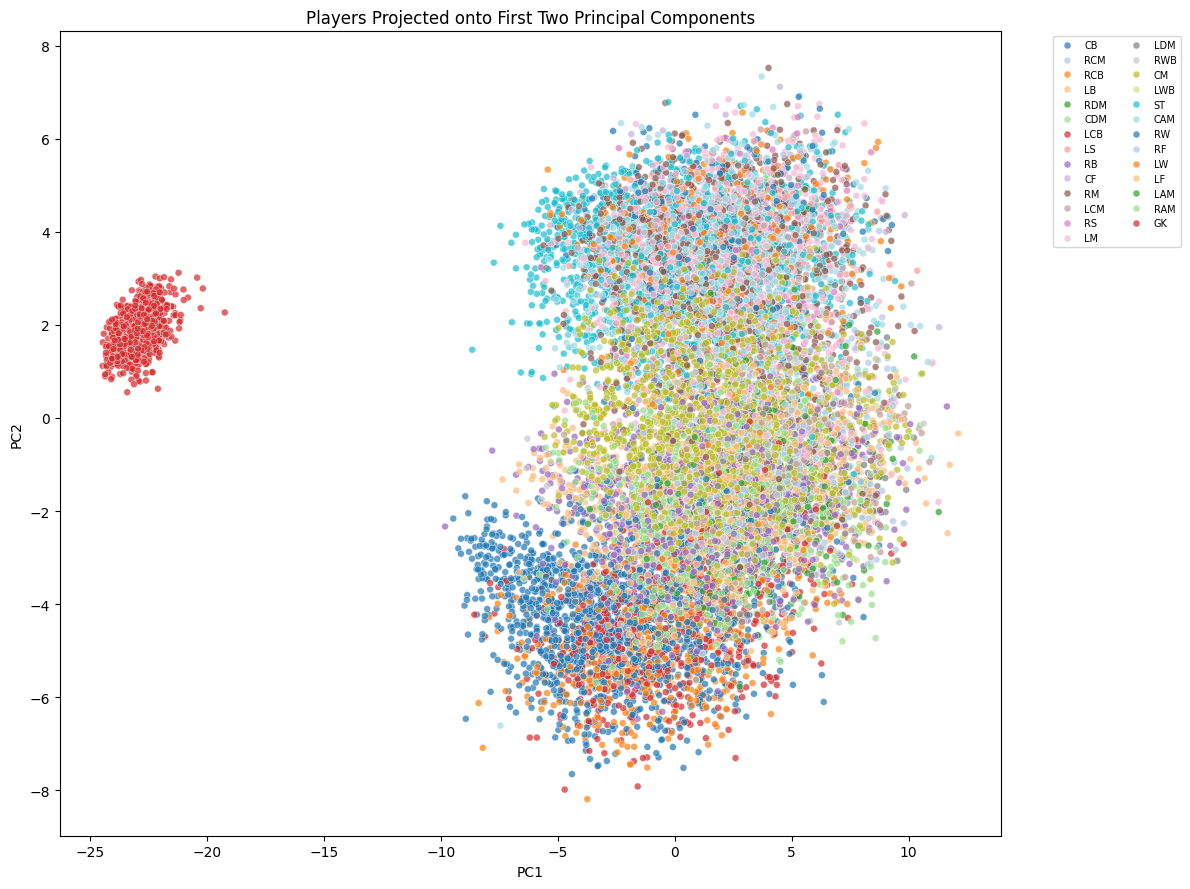

In [257]:
projection_matrix = eigenvectors[:, :2]
projected_data = standardized_df.values @ projection_matrix

pc_df = pd.DataFrame(projected_data[:, :2], columns=['PC1', 'PC2'], index=standardized_df.index)
pc_df['Position'] = decoded_df.loc[standardized_df.index, 'Position']

explained_variance_ratio = eigenvalues[:2] / eigenvalues.sum()
print(explained_variance_ratio.sum()) #0.68 explained  variance

plt.figure(figsize=(12, 9))
sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='Position', palette='tab20', s=25, alpha=0.7)
plt.title('Players Projected onto First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


#### PCA -3

In [ ]:
# i made AI write this part completely for my curiosity 

projection_matrix = eigenvectors[:, :3]
projected_data = standardized_df.values @ projection_matrix

pc_df = pd.DataFrame(projected_data, columns=['PC1', 'PC2', 'PC3'], index=standardized_df.index)
pc_df['Position'] = decoded_df.loc[standardized_df.index, 'Position']

position_groups = {
    'GK': ['GK'],
    'DEF': ['LB','LCB','CB','RCB','RB','LWB','RWB'],
    'MID': ['LDM','CDM','RDM','LM','LCM','CM','RCM','RM','LAM','CAM','RAM'],
    'ATTACK': ['LW','RW','LF','CF','RF','LS','ST','RS']
}

def map_position_group(pos):
    for group, positions in position_groups.items():
        if pos in positions:
            return group
    return 'Other'

pc_df['Position_Group'] = pc_df['Position'].apply(map_position_group)

explained_variance_ratio = eigenvalues[:3] / eigenvalues.sum()
print(explained_variance_ratio.sum())  # explains

fig = px.scatter_3d(
    pc_df, x='PC1', y='PC2', z='PC3',
    color='Position_Group',
    category_orders={'Position_Group': ['GK', 'DEF', 'MID', 'ATTACK']},
    color_discrete_map={'GK': 'red', 'DEF': 'blue', 'MID': 'green', 'ATTACK': 'orange'},
    opacity=0.6,
    title='First Three Principal Components (Grouped by Role)'
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(width=1000, height=800, legend=dict(itemsizing='constant'))
fig.show()


# makes  sense that GK are far away from the rest

0.7481015143018758
